In [1]:
import os
import sys

sys.path.append(os.path.join(os.path.dirname(__vsc_ipynb_file__), ".."))

import numpy as np
import numba
import matplotlib.pyplot as plt

from params import RestrepoParams
from cpu import *
from utils import time_renormalisation
from sde import mean_reverting_gbm, levy_ou_process

In [3]:
def ccdf(arr: npt.NDArray):
    ps = np.arange(1, len(arr)+1) / len(arr)
    vals = np.sort(arr)[::-1]
    return ps, vals

In [4]:
params = RestrepoParams()

In [66]:
params.tau_u

125.0

In [5]:
def cp_iter(cs, cjsr, ryr_open):
    kr = (params.Jmax / params.vp) * ryr_open
    return (cs + params.tau_ps * (kr * cjsr)) / (1.0 + params.tau_ps * kr)

In [6]:
cps = cp_iter(0.1, 70.0, np.linspace(0,1,num=1000))

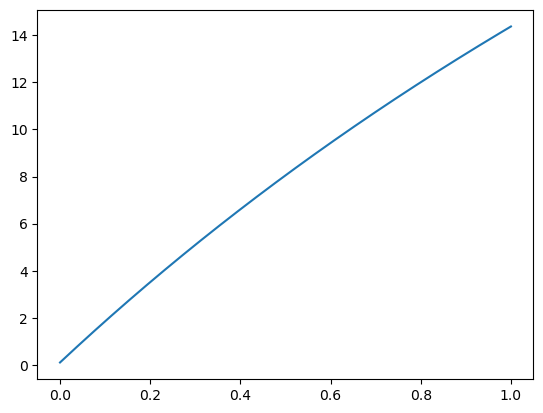

In [7]:
plt.plot(np.linspace(0,1,num=1000), cps)
plt.show()

In [8]:
nb_cru = RestrepoCPU()

In [9]:
nb_cru.forward(1e-3, 5_000_000)

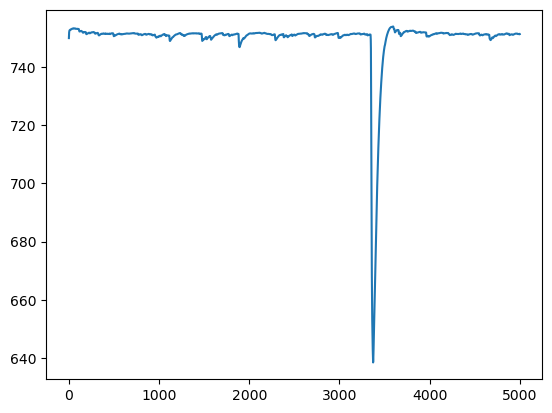

In [67]:
plt.plot(nb_cru.t, nb_cru.cnsr)
plt.show()

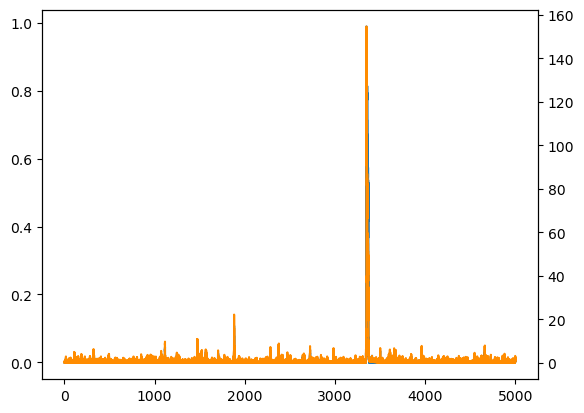

In [10]:
fig, ax = plt.subplots(1)
ax.plot(nb_cru.t, nb_cru.RyR[:, 1] + nb_cru.RyR[:, 2])
ax_right = ax.twinx()
ax_right.plot(nb_cru.t, nb_cru.cp, color='darkorange')
plt.show()

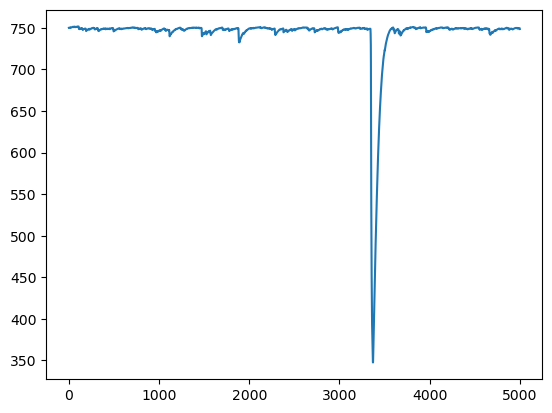

In [11]:
plt.plot(nb_cru.t[::1000], nb_cru.cjsr[::1000])
plt.show()

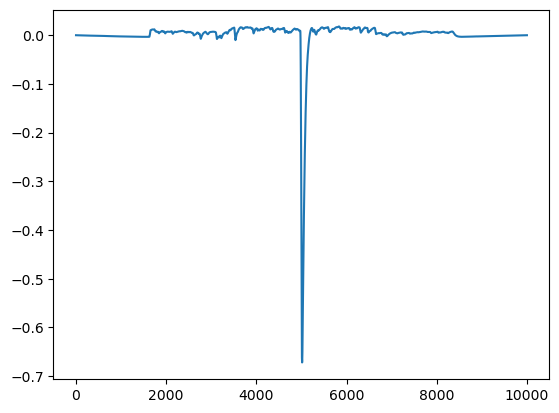

In [12]:
cjsr_shift = nb_cru.cjsr[::1000] - nb_cru.cjsr[::1000].mean()
RyR_shift = (nb_cru.RyR[::1000, 1] + nb_cru.RyR[::1000, 2]) - (nb_cru.RyR[::1000, 1] + nb_cru.RyR[::1000, 2]).mean()
plt.plot(np.correlate(cjsr_shift, RyR_shift, mode='full') / np.sqrt(np.sum(cjsr_shift**2)*np.sum(RyR_shift**2)))
plt.show()

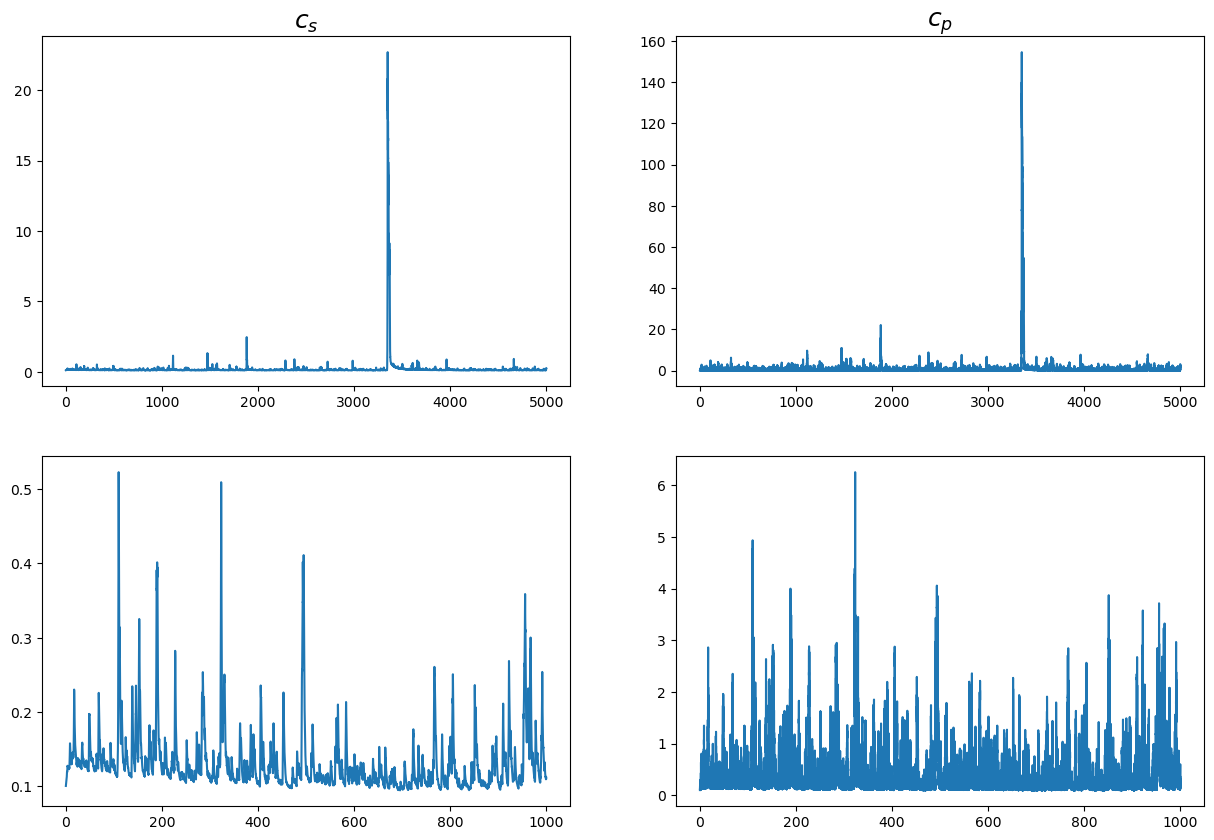

In [13]:
fig, ax = plt.subplots(2,2, figsize=(15,10))
ax[0,0].set_title(r"$c_s$", fontsize=18)
ax[0,0].plot(nb_cru.t, nb_cru.cs)
ax[1,0].plot(nb_cru.t[:1_000_000], nb_cru.cs[:1_000_000])

ax[0,1].set_title(r"$c_p$", fontsize=18)
ax[0,1].plot(nb_cru.t, nb_cru.cp)
ax[1,1].plot(nb_cru.t[:1_000_000], nb_cru.cp[:1_000_000])
plt.show()

In [14]:
t_rn, cs_rn = time_renormalisation(nb_cru.cs, nb_cru.t, niter=10)
_, cp_rn = time_renormalisation(nb_cru.cp, nb_cru.t, niter=10)

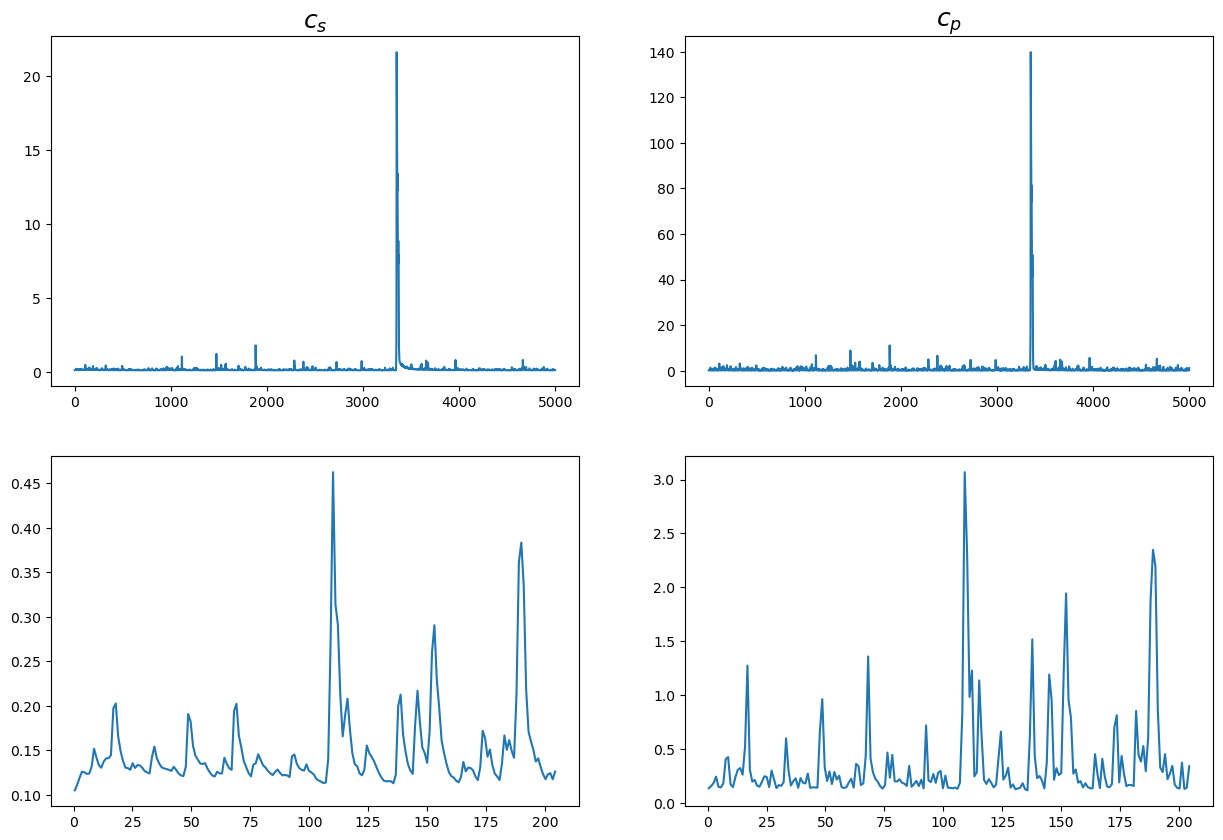

In [15]:
fig, ax = plt.subplots(2,2, figsize=(15,10))
ax[0,0].set_title(r"$c_s$", fontsize=18)
ax[0,0].plot(t_rn, cs_rn)
ax[1,0].plot(t_rn[:200], cs_rn[:200])

ax[0,1].set_title(r"$c_p$", fontsize=18)
ax[0,1].plot(t_rn, cp_rn)
ax[1,1].plot(t_rn[:200], cp_rn[:200])
plt.show()

In [26]:
mu = (cs_rn[cs_rn< 2.0] - cs_rn.min()).mean()
r = 0.084
sigma = np.sqrt(2*r*(mu*(1/(cs_rn[cs_rn<2.0] - cs_rn.min()+1e-3)).mean()-1))
ts, gbm = mean_reverting_gbm(mu, mu, sigma, r, 1e-3, 10_000_000)

In [27]:
sigma**2 / (2*r)

1.5524023797399789

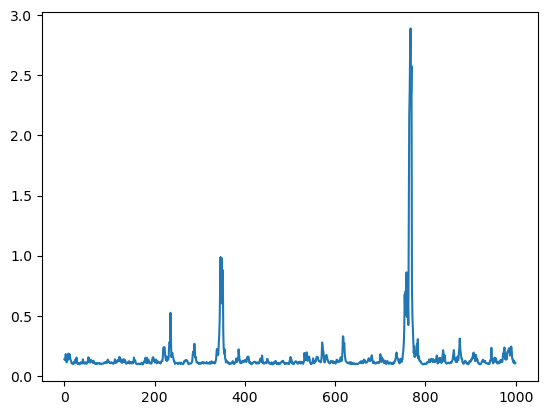

In [28]:
plt.plot(ts[:1_000_000:1000], gbm[:1_000_000:1000] + cs_rn.min())
plt.show()

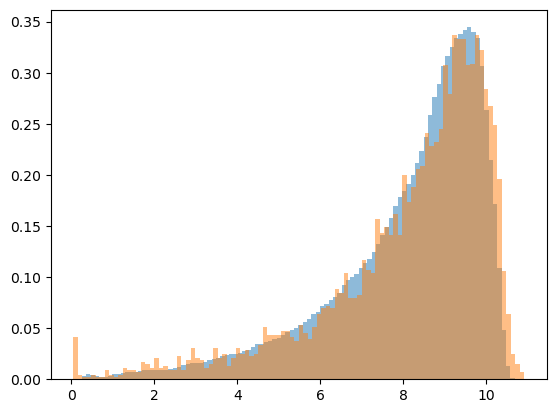

In [29]:
plt.hist(1 / (gbm + cs_rn.min()), density=True, alpha=0.5, bins=100)
plt.hist(1 / cs_rn, density=True, alpha=0.5, bins=100)
plt.show()

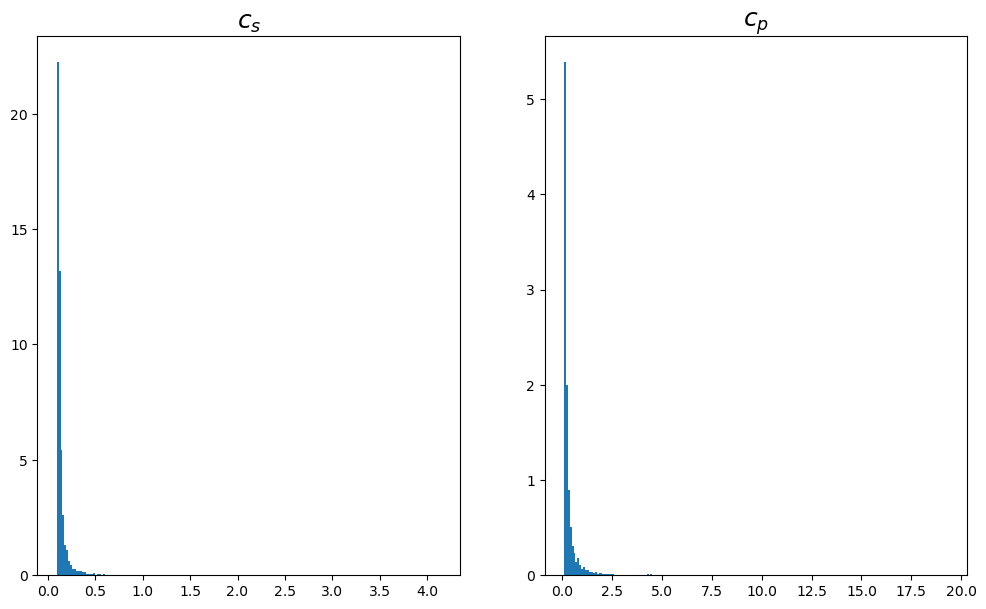

In [30]:
fig, ax = plt.subplots(1,2, figsize=(12,7))
ax[0].set_title(r"$c_s$", fontsize=18)
ax[0].hist(cs_rn[cs_rn < 5.0], bins=200, density=True)
ax[1].set_title(r"$c_p$", fontsize=18)
ax[1].hist(cp_rn[cp_rn < 20], bins=200, density=True)
plt.show()

In [53]:
m_cs = ((cs_rn[cs_rn < 5.0]-cs_rn.min())).mean()
v_cs = ((cs_rn[cs_rn < 5.0]-cs_rn.min())).var()

m_cp = ((cp_rn[cp_rn < 20.0]-cp_rn.min())).mean()
v_cp = ((cp_rn[cp_rn < 20.0]-cp_rn.min())).var()

In [54]:
alpha_cs = 2 + m_cs**2 / v_cs
beta_cs = (alpha_cs - 1) * m_cs

alpha_cp = 2 + m_cp**2 / v_cp
beta_cp = (alpha_cp - 1) * m_cp

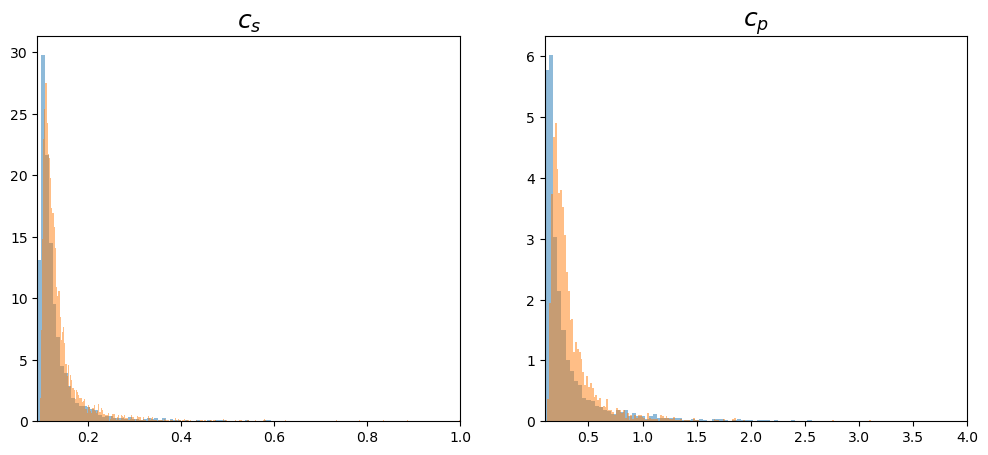

In [58]:
#log_cs_shifted = np.log((np.sort(cs_rn[cs_rn < 2.0])[1:] - cs_rn.min()))
#log_cp_shifted = np.log((np.sort(cp_rn[cp_rn < 20.0])[1:] - cp_rn.min()))

gammas_cs = np.random.gamma(shape=alpha_cs, scale=1/beta_cs, size=cs_rn.shape[0])
gammas_cp = np.random.gamma(shape=alpha_cp, scale=1/beta_cp, size=cp_rn.shape[0])

ig_cs = 1 / gammas_cs + cs_rn.min()
ig_cp = 1 / gammas_cp + cp_rn.min()


fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].set_title(r"$c_s$", fontsize=18)
ax[0].hist((cs_rn[cs_rn < 5.0]), bins=500, density=True, alpha=0.5)
ax[0].hist(ig_cs[ig_cs<5.0], bins=500, density=True, alpha=0.5)
ax[0].set_xlim(cs_rn.min(),1)

ax[1].set_title(r"$c_p$", fontsize=18)
ax[1].hist(cp_rn[cp_rn < 20.0], bins=500, density=True, alpha=0.5)
ax[1].hist(ig_cp[ig_cp < 20.0], bins=500, density=True, alpha=0.5)
ax[1].set_xlim(cp_rn.min(),4)
plt.show()

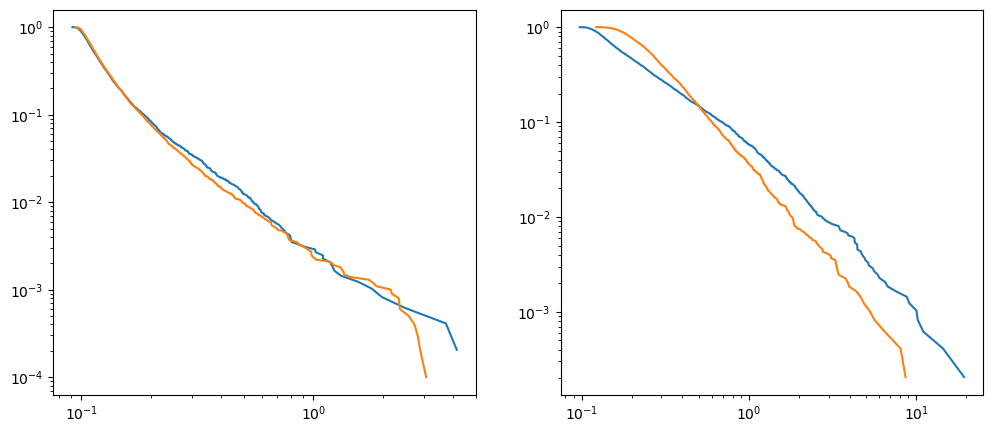

In [59]:
cs_ps, cs_bins = ccdf(cs_rn[cs_rn < 5.0])
cp_ps, cp_bins = ccdf(cp_rn[cp_rn < 20.0])

ig_cs_ps, ig_cs_bins = ccdf(gbm[::1000] + cs_rn[500:].min())
ig_cp_ps, ig_cp_bins = ccdf(ig_cp)

fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(cs_bins, cs_ps)
ax[0].plot(ig_cs_bins, ig_cs_ps)
ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].plot(cp_bins, cp_ps)
ax[1].plot(ig_cp_bins, ig_cp_ps)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
plt.show()

In [20]:
def acf(arr: npt.NDArray, demean: bool = True):
    if demean:
        x = arr - arr.mean()
    else:
        x = arr

    corr = np.correlate(x, x, mode='full')
    corr /= np.dot(x, x)
    return corr[len(corr)//2:]

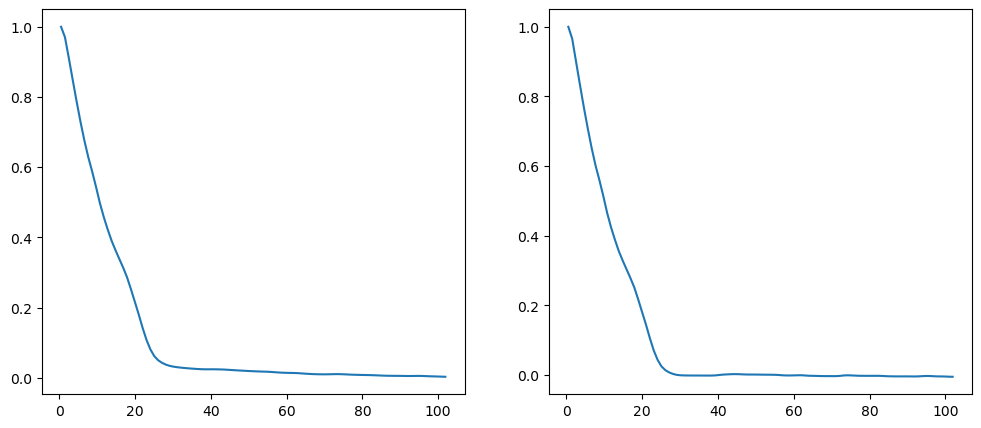

In [21]:
cs_acf = acf(cs_rn)
cp_acf = acf(cp_rn)

fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(t_rn[:100], cs_acf[:100])
ax[1].plot(t_rn[:100], cp_acf[:100])
plt.show()

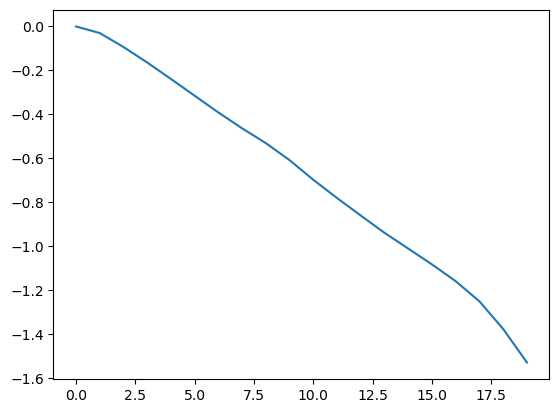

In [22]:
plt.plot(np.log(cs_acf[:20]))
plt.show()

In [25]:
np.log(cs_acf[20] / cs_acf[0]) / (t_rn[20] - t_rn[0])

-0.08350171727387186

In [26]:
# Delete big arrays
try:
    del nb_cru
except:
    pass

In [2]:
b_cru = RestrepoCPU(boundary=True)

In [50]:
V = -40.0
Nai = 78.0

In [87]:
b_cru.forward(1e-3, 50_000_000, V=V, Nai=Nai)

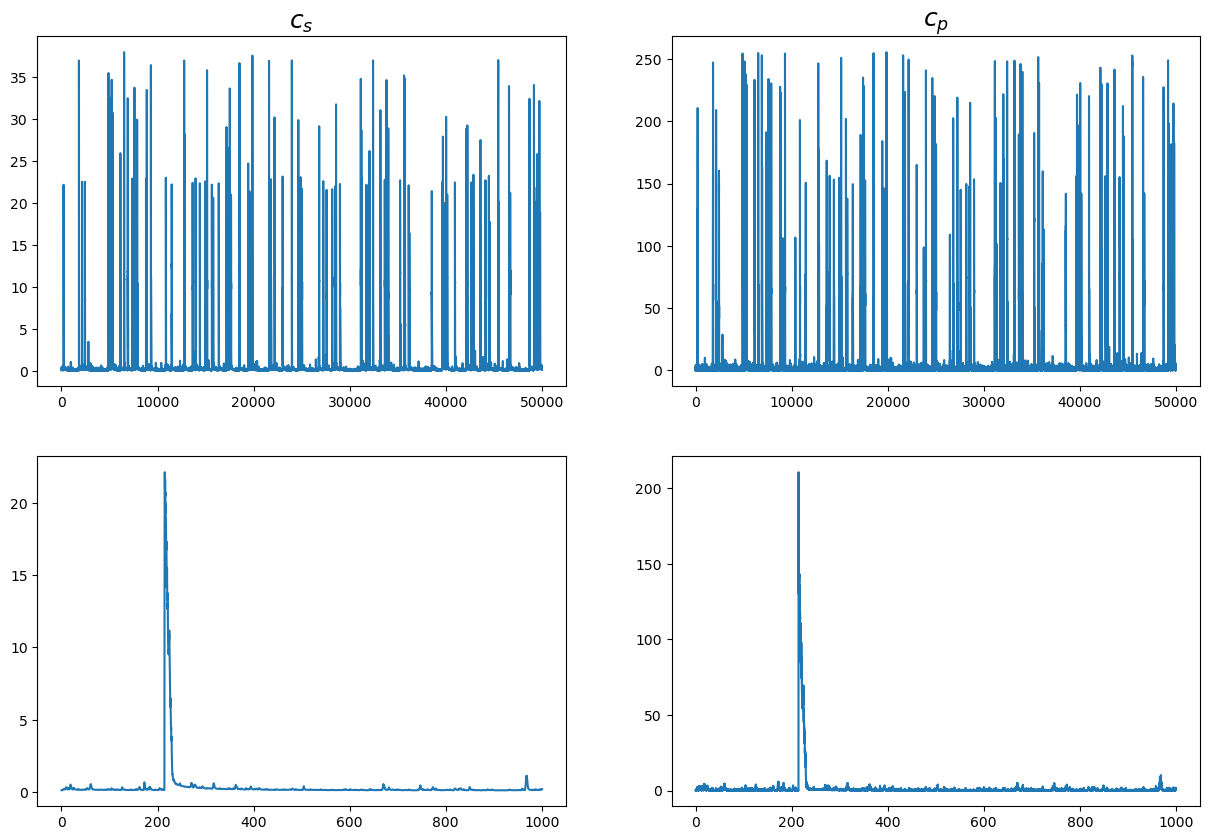

In [88]:
fig, ax = plt.subplots(2,2, figsize=(15,10))
ax[0,0].set_title(r"$c_s$", fontsize=18)
ax[0,0].plot(b_cru.t, b_cru.cs)
ax[1,0].plot(b_cru.t[:1_000_000], b_cru.cs[:1_000_000])

ax[0,1].set_title(r"$c_p$", fontsize=18)
ax[0,1].plot(b_cru.t, b_cru.cp)
ax[1,1].plot(b_cru.t[:1_000_000], b_cru.cp[:1_000_000])
plt.show()

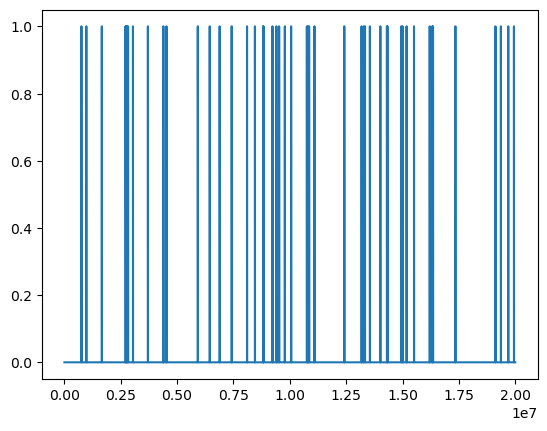

In [59]:
plt.plot((b_cru.LCC == 7).sum(axis=-1))
plt.show()

In [89]:
t_rn, cs_rn = time_renormalisation(b_cru.cs, b_cru.t, niter=10)
_, cp_rn = time_renormalisation(b_cru.cp, b_cru.t, niter=10)

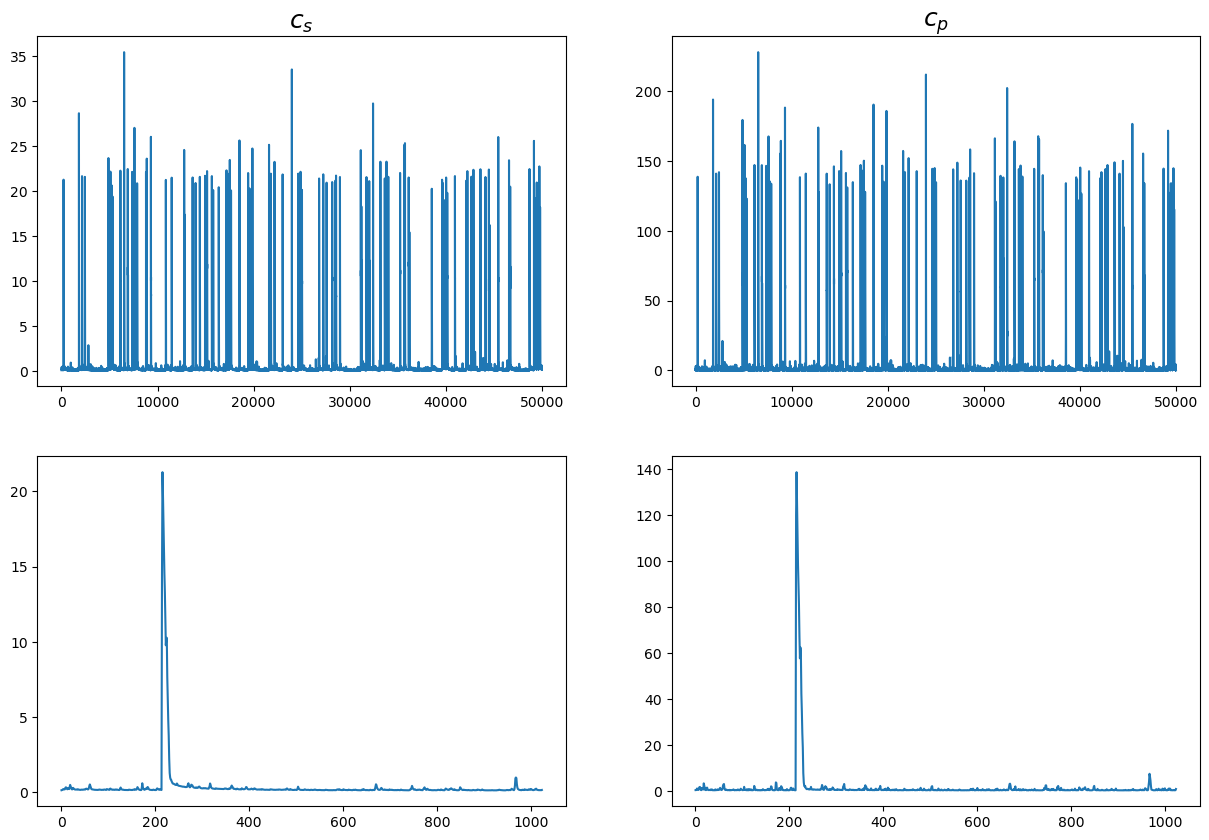

In [90]:
fig, ax = plt.subplots(2,2, figsize=(15,10))
ax[0,0].set_title(r"$c_s$", fontsize=18)
ax[0,0].plot(t_rn, cs_rn)
ax[1,0].plot(t_rn[:1000], cs_rn[:1000])

ax[0,1].set_title(r"$c_p$", fontsize=18)
ax[0,1].plot(t_rn, cp_rn)
ax[1,1].plot(t_rn[:1000], cp_rn[:1000])
plt.show()

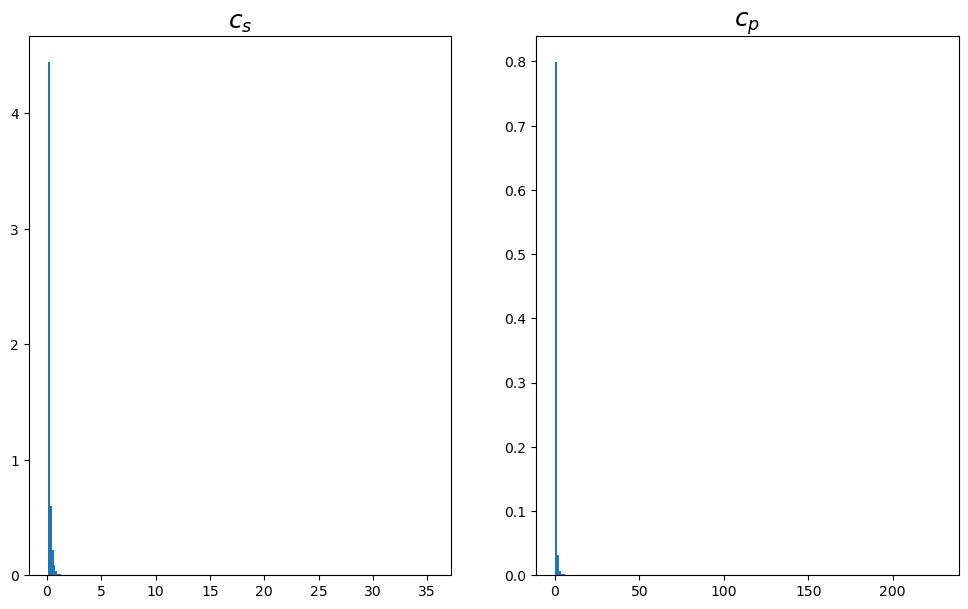

In [91]:
fig, ax = plt.subplots(1,2, figsize=(12,7))
ax[0].set_title(r"$c_s$", fontsize=18)
ax[0].hist(cs_rn, bins=200, density=True)
ax[1].set_title(r"$c_p$", fontsize=18)
ax[1].hist(cp_rn, bins=200, density=True)
plt.show()

In [92]:
p_cp, bins_cp = ccdf(cp_rn)
p_cs, bins_cs = ccdf(cs_rn)

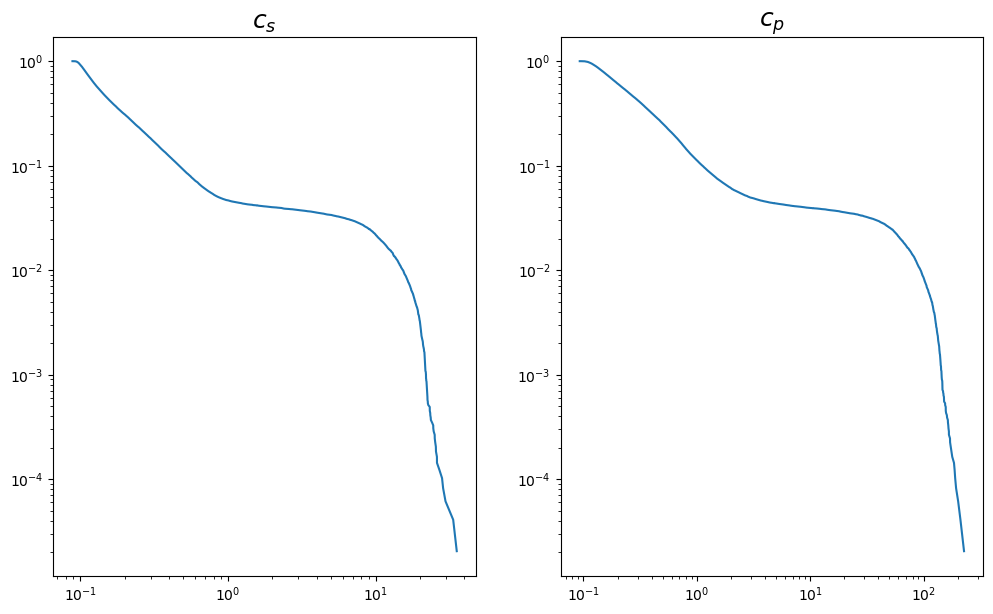

In [93]:
fig, ax = plt.subplots(1,2, figsize=(12,7))
ax[0].set_title(r"$c_s$", fontsize=18)
ax[0].plot(bins_cs, p_cs)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_title(r"$c_p$", fontsize=18)
ax[1].plot(bins_cp, p_cp)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
plt.show()

In [94]:
jump_candidates = t_rn[np.where(cs_rn > 2.0)[0]]

In [95]:
actual_jump_pos = np.where(jump_candidates[1:] - jump_candidates[:-1] > 2.0)[0]

In [96]:
jumps = np.zeros(len(actual_jump_pos))
for i in range(len(actual_jump_pos)):
    if i == 0:
        left = 0
    else:
        left = actual_jump_pos[i-1]
    right = actual_jump_pos[i]
    jumps[i] = jump_candidates[left:right].mean()

In [97]:
ijt_ps, ijt_bins = ccdf(jumps[1:] - jumps[:-1])

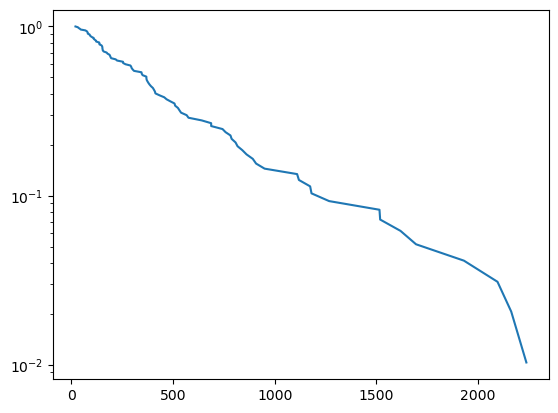

In [98]:
plt.plot(ijt_bins, ijt_ps)
plt.yscale('log')
plt.show()